In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
throughput_fp = "outputs/throughput_results.csv"

throughput_data = pd.read_csv(throughput_fp)
throughput_data.head()

,Batch Size,Time Per Batch (Loading),Time Per Batch (Inference),Total Time Per Batch,Overall Total
0,5,0.6563,0.0098,0.6661,835.3257
1,10,0.5706,0.0106,0.5811,364.3772
2,15,0.9590,0.0110,0.9701,405.4874
3,20,1.2616,0.0114,1.2730,399.7254
4,25,1.5938,0.0115,1.6053,402.9395


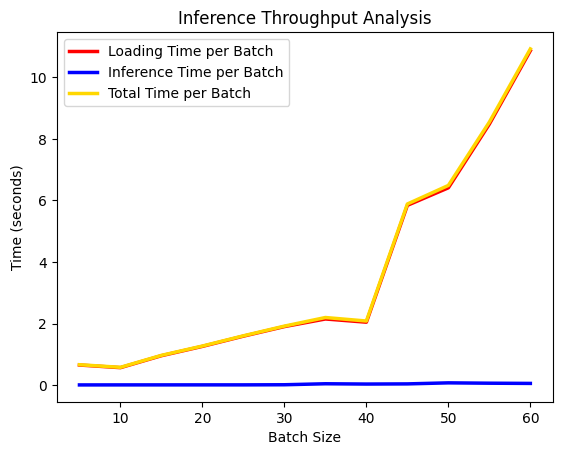

In [3]:
plt.plot(throughput_data["Batch Size"], throughput_data["Time Per Batch (Loading)"], color = "red", lw = 2.5, label="Loading Time per Batch")
plt.plot(throughput_data["Batch Size"], throughput_data["Time Per Batch (Inference)"], color = "blue", lw = 2.5, label="Inference Time per Batch")
plt.plot(throughput_data["Batch Size"], throughput_data["Total Time Per Batch"], color = "gold", lw = 2.5, label="Total Time per Batch")
plt.xlabel("Batch Size")
plt.ylabel("Time (seconds)")
plt.title("Inference Throughput Analysis")
plt.legend()

In [34]:
inference_fp = "outputs/inference_results.csv"
inference_data = pd.read_csv(inference_fp, sep = ",", header = None, names = ["id", "img_url", "img_path", "predicted_label", "predicted_label_name"])
inference_data.head()

,id,img_url,img_path,predicted_label,predicted_label_name
0,1125704,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125704.jpg,1,Abnormal
1,1125723,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125723.jpg,0,Normal
2,1125735,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125735.jpg,1,Abnormal
3,1125800,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125800.jpg,1,Abnormal
4,1125822,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125822.jpg,0,Normal


In [35]:
binarize_data = True

data_fp  = "camera_data/unseen_cameras_data.csv"
camera_data = pd.read_csv(data_fp)
camera_data = camera_data.dropna()
camera_data["choice"] = camera_data["choice"].str.extract(r"(\d)").astype(int) - 1
if binarize_data:
    camera_data["choice"] = camera_data["choice"].apply(lambda x: -1 if x < 0 else 1 if x > 1 else 0)
camera_data.head()

,annotation_id,annotator,choice,created_at,id,image,lead_time,ptz,updated_at,location
0,56756,10,1,2026-03-02T22:52:53.536733Z,1125704,https://tools.alertcalifornia.org/fireframes5/...,3.300,"{""pan"":278.17999267578125,""tilt"":-0.3300000131...",2026-03-02T22:52:53.536750Z,Dewdrop
1,56661,11,0,2026-03-02T21:56:18.051767Z,1125723,https://tools.alertcalifornia.org/fireframes5/...,1.012,"{""pan"":278.17999267578125,""tilt"":-0.3300000131...",2026-03-02T21:56:18.051784Z,Dewdrop
2,56700,11,0,2026-03-02T22:17:39.795932Z,1125735,https://tools.alertcalifornia.org/fireframes5/...,4.158,"{""pan"":278.17999267578125,""tilt"":-0.3300000131...",2026-03-02T22:17:39.795950Z,Dewdrop
3,56654,11,1,2026-03-02T21:55:33.701104Z,1125800,https://tools.alertcalifornia.org/fireframes5/...,10.034,"{""pan"":278.17999267578125,""tilt"":-0.3300000131...",2026-03-02T21:55:41.471511Z,Dewdrop
4,56872,10,0,2026-03-02T22:58:23.727564Z,1125822,https://tools.alertcalifornia.org/fireframes5/...,3.669,"{""pan"":278.17999267578125,""tilt"":-0.3300000131...",2026-03-02T22:58:23.727582Z,Dewdrop


In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

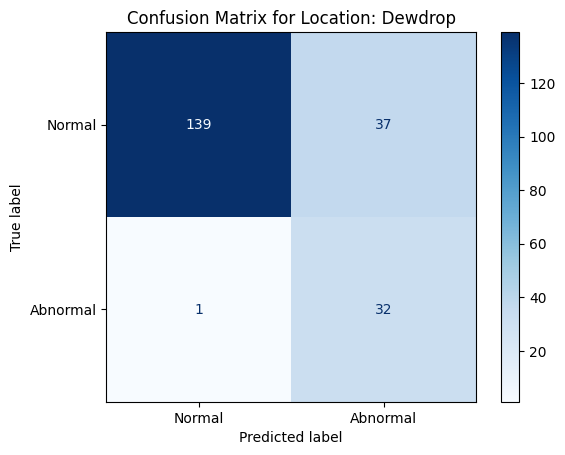

Accuracy for Dewdrop: 0.8182


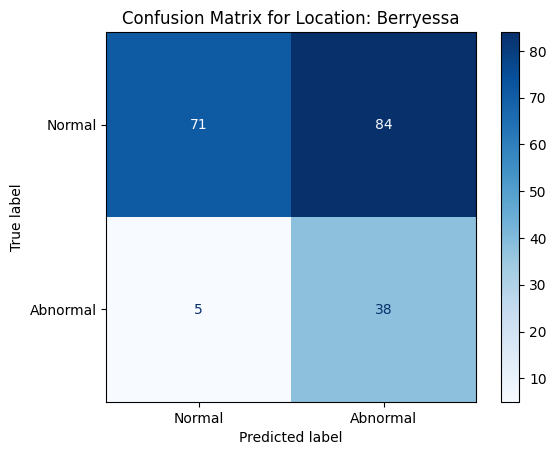

Accuracy for Berryessa: 0.5505


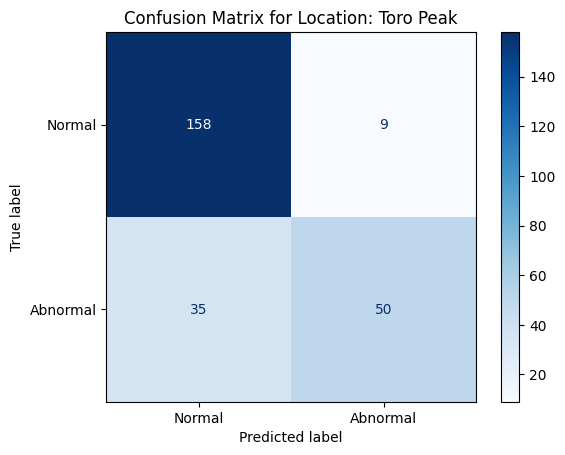

Accuracy for Toro Peak: 0.8254
Overall Accuracy: 0.7405


In [ ]:
choice_and_predictions = pd.merge(camera_data, inference_data, left_on = "id", right_on = "id", how = "inner")

for location in choice_and_predictions["location"].unique():
    subset = choice_and_predictions[choice_and_predictions["location"] == location]
    plot_confusion_matrix(subset['choice'], subset['predicted_label'], title=f"Confusion Matrix for Location: {location}")
    print(f"Accuracy for {location}: {(subset['choice'] == subset['predicted_label']).mean():.4f}")

plot_confusion_matrix(choice_and_predictions['choice'], choice_and_predictions['predicted_label'], title=f"Overall Confusion Matrix")
print(f"Overall Accuracy: {(choice_and_predictions['choice'] == choice_and_predictions['predicted_label']).mean():.4f}")